# Who Said It? — EDA & Preprocessing

6 years of Discord messages, Naive Bayes classifier.  
This notebook covers exploratory data analysis and text preprocessing, producing a clean dataset ready for training.

In [1]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_PATH = '../data/messages.csv'
AUTHORS_PATH = '../authors.json'  # private mapping — gitignored
MIN_MESSAGES = 200

with open(AUTHORS_PATH) as f:
    AUTHOR_MAP = json.load(f)

## 1. Load & Initial Inspection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (54240, 8)


,channel_name,message_id,author_username,author_display_name,created_at_iso,content,is_bot,attachments
0,general,755304415908593745,justfresher,CGL MAFDY,2020-09-15T05:50:05.630000+00:00,Lets gooo,False,NaN
1,general,755304483629695076,punkkluvv,punkk,2020-09-15T05:50:21.776000+00:00,god damn,False,NaN
2,general,755304539715797052,punkkluvv,punkk,2020-09-15T05:50:35.148000+00:00,<:xqcKek:721970293203009636> \,False,NaN
3,general,755304562746720356,punkkluvv,punkk,2020-09-15T05:50:40.639000+00:00,https://tenor.com/view/wtf-blink-steve-harvey-...,False,NaN
4,general,755304677108744262,justfresher,CGL MAFDY,2020-09-15T05:51:07.905000+00:00,https://tenor.com/view/stanley-sleeping-the-of...,False,NaN


In [3]:
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

channel_name               str
message_id               int64
author_username            str
author_display_name        str
created_at_iso             str
content                    str
is_bot                    bool
attachments            float64
dtype: object

Null counts:
channel_name               0
message_id                 0
author_username            0
author_display_name        0
created_at_iso             0
content                    2
is_bot                     0
attachments            54240
dtype: int64


## 2. Filter Authors

In [4]:
author_counts = df['author_display_name'].value_counts()
keep = author_counts[author_counts >= MIN_MESSAGES].index
df = df[df['author_display_name'].isin(keep)].copy()

# anonymise: map real display names -> Person A/B/C...
df['author'] = df['author_display_name'].map(AUTHOR_MAP)
print(f'Kept {len(keep)} authors, {len(df)} messages')
print(df['author'].value_counts().to_string())

Kept 8 authors, 53963 messages
author
Person A    11751
Person B    10809
Person C     8899
Person D     7366
Person E     5476
Person F     4869
Person G     3463
Person H     1330


## 3. EDA

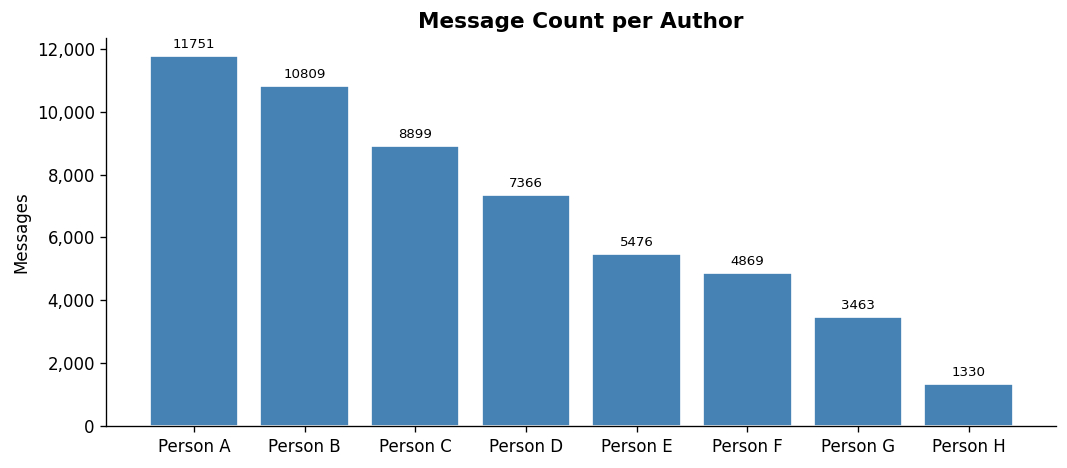

Class imbalance ratio (max/min): 8.84


In [5]:
# --- Message counts per author ---
counts = df['author'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Message Count per Author', fontsize=13, fontweight='bold')
ax.set_ylabel('Messages')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print('Class imbalance ratio (max/min):', round(counts.max() / counts.min(), 2))

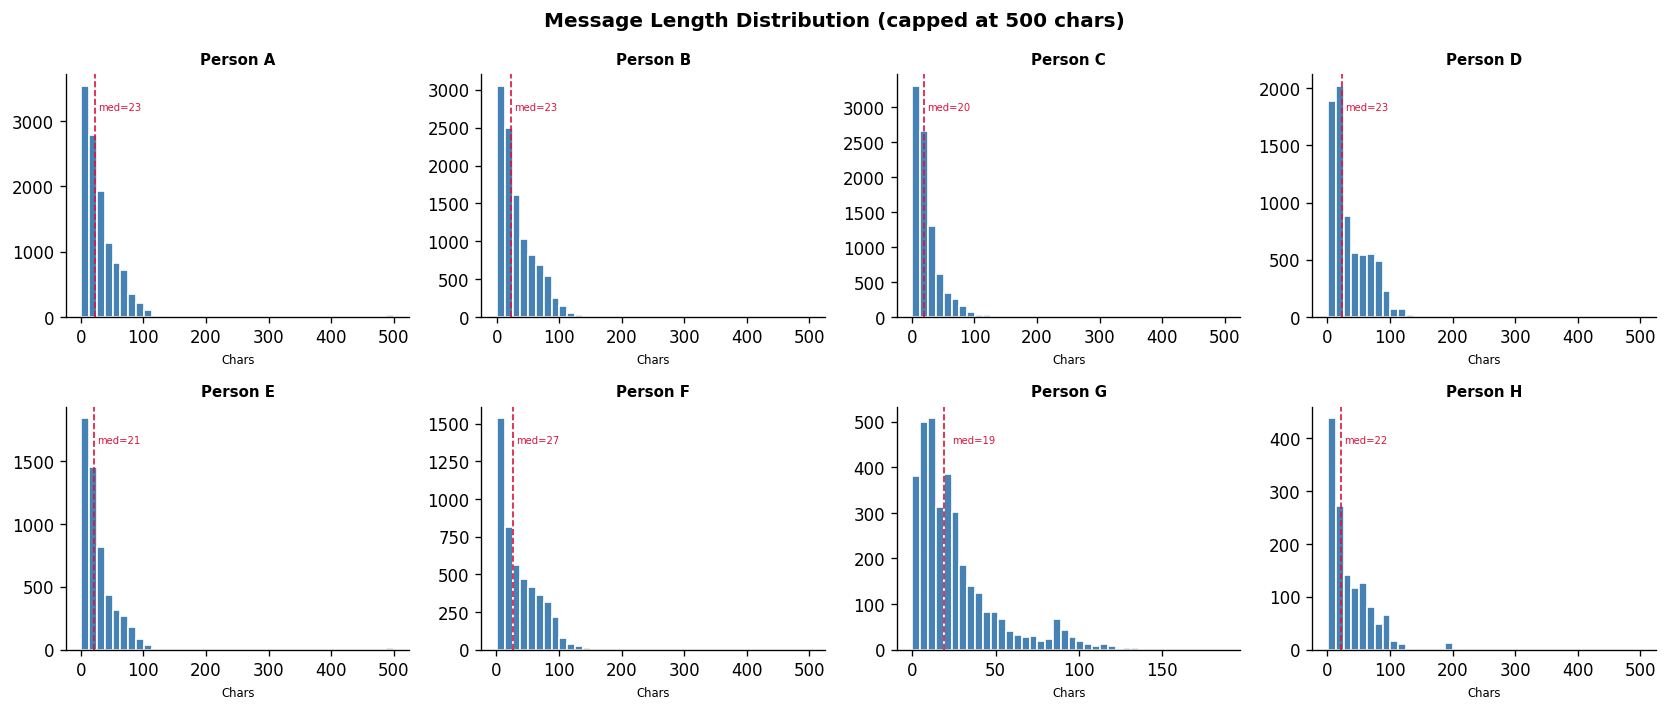

In [6]:
# --- Message length distribution ---
df['msg_len'] = df['content'].fillna('').astype(str).str.len()

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for i, (author, grp) in enumerate(df.groupby('author')):
    lengths = grp['msg_len'].clip(upper=500)
    axes[i].hist(lengths, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(author, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Chars', fontsize=7)
    median = lengths.median()
    axes[i].axvline(median, color='crimson', linestyle='--', linewidth=1)
    axes[i].text(median + 5, axes[i].get_ylim()[1] * 0.85, f'med={int(median)}', fontsize=6, color='crimson')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Message Length Distribution (capped at 500 chars)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_95992/3854225490.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['created_at'].dt.to_period('M')


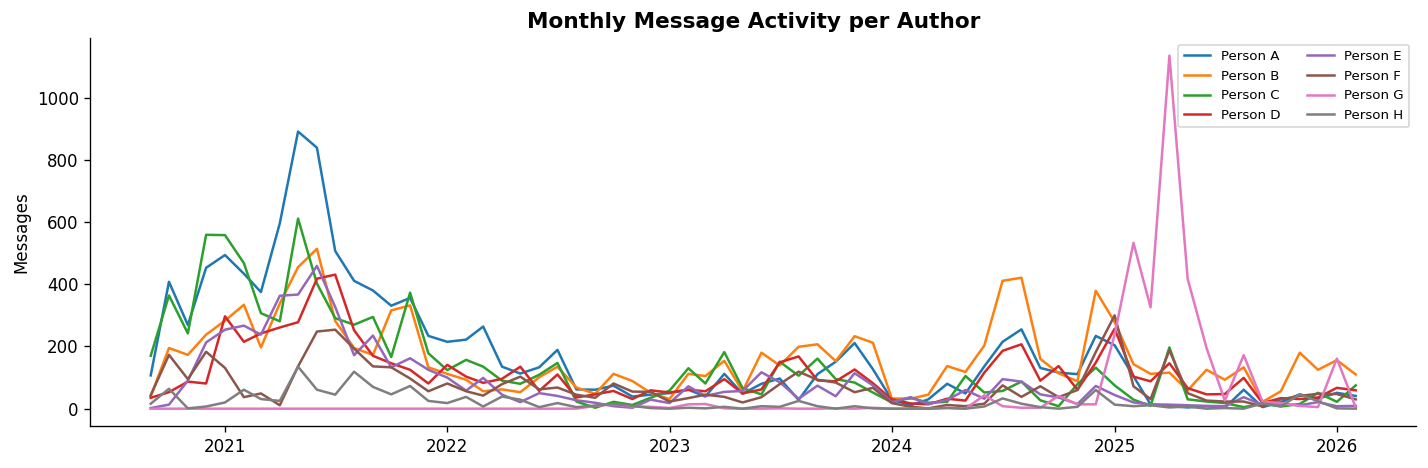

In [7]:
# --- Activity over time ---
df['created_at'] = pd.to_datetime(df['created_at_iso'], format='mixed', utc=True)
df['month'] = df['created_at'].dt.to_period('M')

monthly = df.groupby(['month', 'author']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
for col in monthly.columns:
    ax.plot(monthly.index, monthly[col], label=col, linewidth=1.5)

ax.set_title('Monthly Message Activity per Author', fontsize=13, fontweight='bold')
ax.set_ylabel('Messages')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

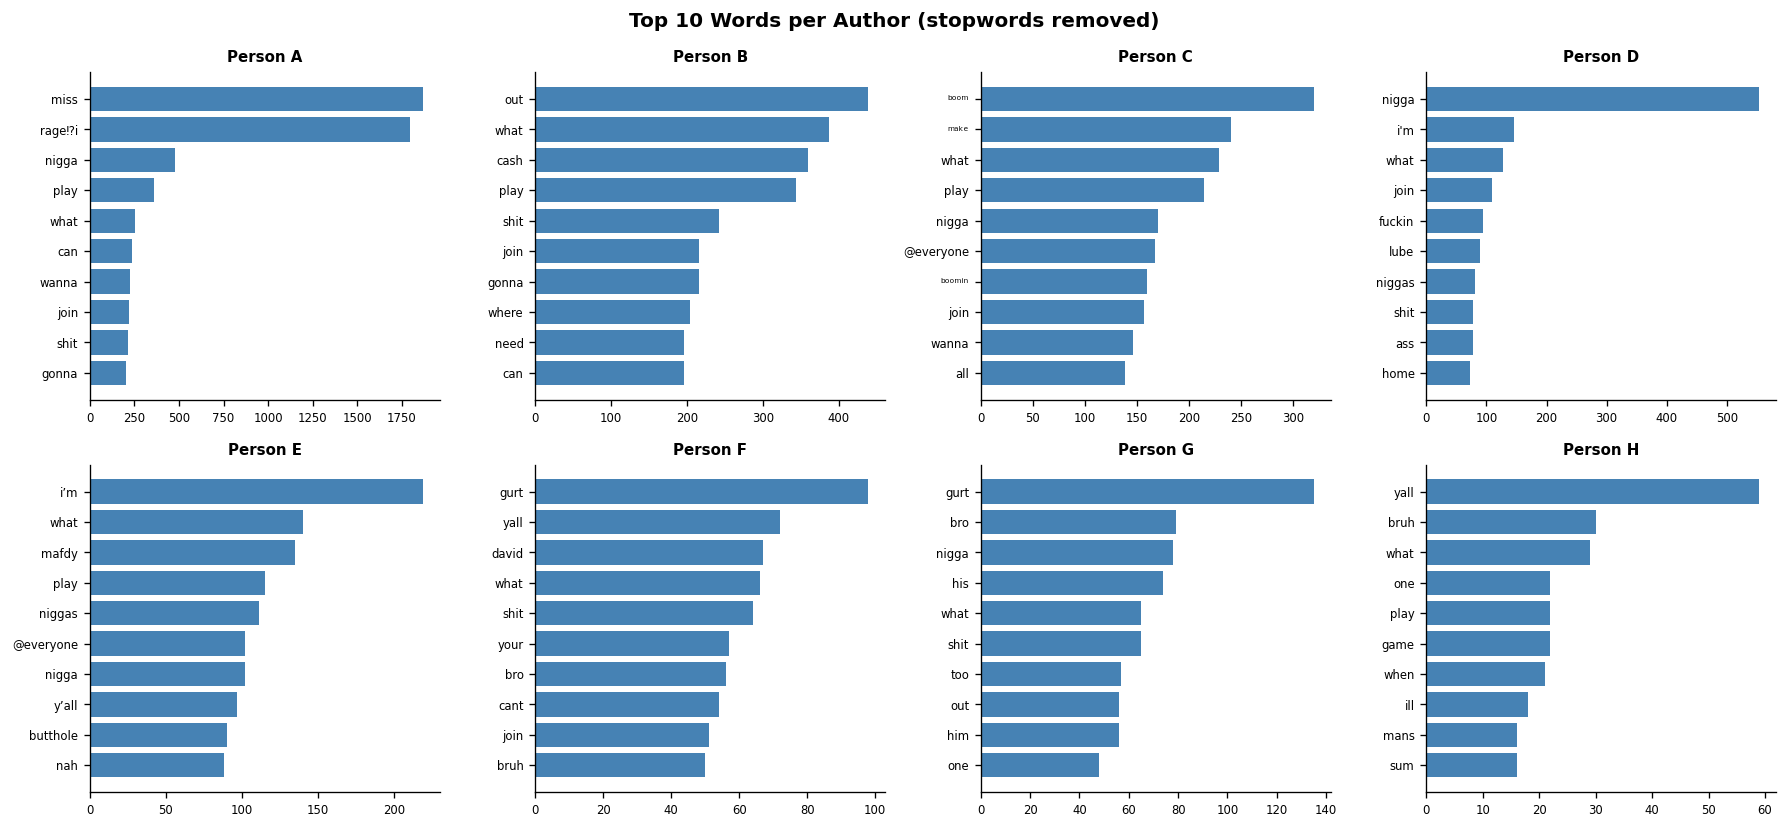

In [8]:
# --- Top words per author (raw, before cleaning) ---
from collections import Counter

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','it',
    'i','you','he','she','they','we','that','this','was','be','have','do','not',
    'with','are','my','so','just','like','its','as','if','yeah','yea','no','yes',
    'im','ive','its','ur','u','lol','lmao','oh','ok','okay','go','get','got'
}

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, (author, grp) in enumerate(df.groupby('author')):
    words = ' '.join(grp['content'].fillna('').astype(str)).lower().split()
    words = [w.strip('.,!?;:\'"()[]') for w in words if w not in STOPWORDS and len(w) > 2 and not w.startswith('<') and not w.startswith('http')]
    top = Counter(words).most_common(10)
    if not top:
        continue
    labels, vals = zip(*top)
    axes[i].barh(labels[::-1], vals[::-1], color='steelblue')
    axes[i].set_title(author, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 10 Words per Author (stopwords removed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [9]:
def clean_text(text: str) -> str:
    """Normalise a Discord message for classification."""
    if not isinstance(text, str):
        return ''
    # remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # remove Discord custom emoji  <:name:id>
    text = re.sub(r'<:[a-zA-Z0-9_]+:\d+>', '', text)
    # remove Discord mentions  <@id>  <@!id>  <#id>
    text = re.sub(r'<[@#][!&]?\d+>', '', text)
    # remove non-ASCII (covers Unicode emoji)
    text = text.encode('ascii', errors='ignore').decode()
    # collapse whitespace and lower-case
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

# sanity check
samples = [
    'Check this out https://tenor.com/view/wtf-gif-123',
    '<:xqcKek:721970293203009636> bro that was crazy',
    'hey <@!123456789> whats good',
]
for s in samples:
    print(repr(s), '->', repr(clean_text(s)))

'Check this out https://tenor.com/view/wtf-gif-123' -> 'check this out'
'<:xqcKek:721970293203009636> bro that was crazy' -> 'bro that was crazy'
'hey <@!123456789> whats good' -> 'hey whats good'


In [10]:
df['clean_content'] = df['content'].apply(clean_text)

before = len(df)
df = df[df['clean_content'].str.strip() != ''].copy()
print(f'Dropped {before - len(df)} empty rows after cleaning. Remaining: {len(df)}')

Dropped 13207 empty rows after cleaning. Remaining: 40756


In [11]:
# Preview cleaned vs raw (anonymous author column only)
df[['author', 'content', 'clean_content']].sample(10, random_state=42)

,author,content,clean_content
20528,Person A,its today,its today
44058,Person G,Wouldn’t record audio for some reason,wouldnt record audio for some reason
48814,Person D,im abt to shower,im abt to shower
19087,Person C,a classic,a classic
6125,Person F,its me,its me
4247,Person F,There go berlin,there go berlin
15383,Person E,ill give you cummies,ill give you cummies
38580,Person E,igh bro fr stop im going to sleep,igh bro fr stop im going to sleep
12322,Person B,Broo that’s shit had me dying,broo thats shit had me dying
41611,Person A,ngl im getting off at 10 so yall do with that ...,ngl im getting off at 10 so yall do with that ...


## 5. Save Clean Dataset

In [12]:
out = df[['author', 'clean_content']]
out.to_csv('../data/messages_clean.csv', index=False)
print(f'Saved {len(out)} rows to data/messages_clean.csv')
out['author'].value_counts()

Saved 40756 rows to data/messages_clean.csv


author
Person A    9247
Person B    8163
Person C    7280
Person D    4453
Person E    4393
Person F    3163
Person G    3149
Person H     908
Name: count, dtype: int64